In [1]:
# Cell 1 - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Cell 2 - Load the dataset
df = pd.read_csv('data/accidents.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (93, 14)

Columns: ['Sl. No.', 'State/UT/City', 'Road Accidents - Cases', 'Road Accidents - Injured', 'Road Accidents - Died', 'Railway Accidents - Cases', 'Railway Accidents - Injured', 'Railway Accidents - Died', 'Railway Crossing Accidents - Cases', 'Railway Crossing Accidents - Injured', 'Railway Crossing Accidents - Died', 'Total Traffic Accidents - Cases', 'Total Traffic Accidents - Injured', 'Total Traffic Accidents - Died']

First 5 rows:


,Sl. No.,State/UT/City,Road Accidents - Cases,Road Accidents - Injured,Road Accidents - Died,Railway Accidents - Cases,Railway Accidents - Injured,Railway Accidents - Died,Railway Crossing Accidents - Cases,Railway Crossing Accidents - Injured,Railway Crossing Accidents - Died,Total Traffic Accidents - Cases,Total Traffic Accidents - Injured,Total Traffic Accidents - Died
0,1,Andhra Pradesh,21070,21340,8293,1029,0,1037,0,0,0,22099,21340,9330
1,2,Arunachal Pradesh,215,177,152,0,0,0,0,0,0,215,177,152
2,3,Assam,7028,5679,3060,689,0,693,22,0,22,7739,5679,3775
3,4,Bihar,10801,7068,8898,1444,6,1446,52,0,53,12297,7074,10397
4,5,Chhattisgarh,13091,11459,5890,429,21,429,4,0,4,13524,11480,6323


In [3]:
# Cell 3 - Basic info about the dataset
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (93, 14)

Data Types:
Sl. No.                                   str
State/UT/City                             str
Road Accidents - Cases                  int64
Road Accidents - Injured                int64
Road Accidents - Died                   int64
Railway Accidents - Cases               int64
Railway Accidents - Injured             int64
Railway Accidents - Died                int64
Railway Crossing Accidents - Cases      int64
Railway Crossing Accidents - Injured    int64
Railway Crossing Accidents - Died       int64
Total Traffic Accidents - Cases         int64
Total Traffic Accidents - Injured       int64
Total Traffic Accidents - Died          int64
dtype: object

Missing Values:
Sl. No.                                 0
State/UT/City                           0
Road Accidents - Cases                  0
Road Accidents - Injured                0
Road Accidents - Died                   0
Railway Accidents - Cases               0
Railway Accidents - Injured             0
Ra

In [4]:
# Cell 4 - Create Severity Score (fixed)
df['Severity_Score'] = (df['Road Accidents - Died'] * 2) + (df['Road Accidents - Injured'] * 1)

# Split by percentiles instead of equal range
df['Severity_Label'] = pd.qcut(df['Severity_Score'],
                                q=3,
                                labels=['Low', 'Medium', 'High'])

print(df[['State/UT/City', 'Severity_Score', 'Severity_Label']].head(10))
print("\nSeverity Distribution:")
print(df['Severity_Label'].value_counts())

       State/UT/City  Severity_Score Severity_Label
0     Andhra Pradesh           37926           High
1  Arunachal Pradesh             481            Low
2              Assam           11799           High
3              Bihar           24864           High
4       Chhattisgarh           23239           High
5                Goa            1619         Medium
6            Gujarat           30407           High
7            Haryana           18809           High
8   Himachal Pradesh            5849           High
9          Jharkhand           11543           High

Severity Distribution:
Severity_Label
Low       31
Medium    31
High      31
Name: count, dtype: int64


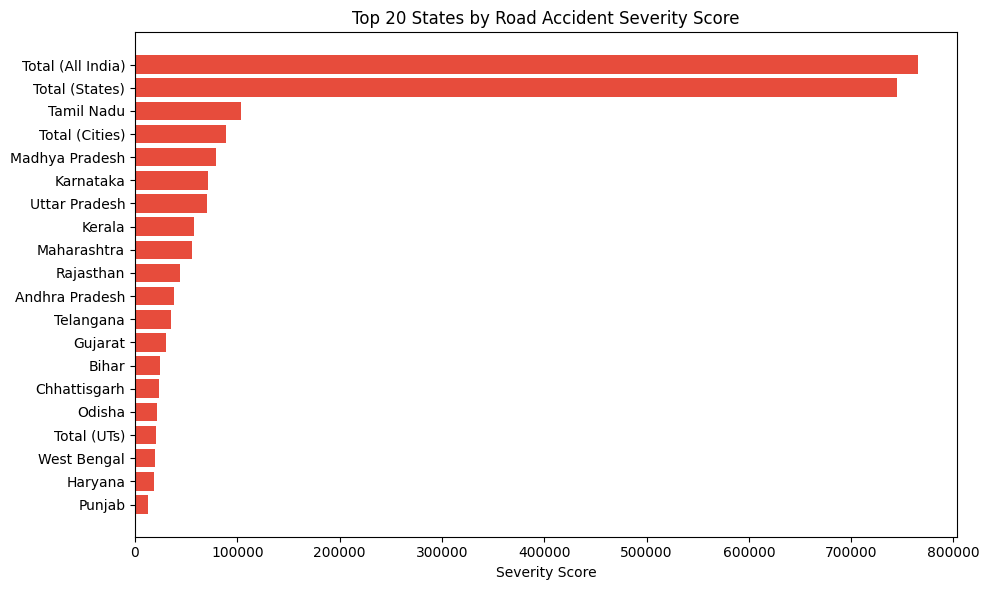

In [5]:
# Cell 5 - Visualise Severity Distribution
plt.figure(figsize=(10, 6))
df_sorted = df.sort_values('Severity_Score', ascending=False).head(20)

colors = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}
bar_colors = [colors[str(label)] for label in df_sorted['Severity_Label']]

plt.barh(df_sorted['State/UT/City'], df_sorted['Severity_Score'], color=bar_colors)
plt.xlabel('Severity Score')
plt.title('Top 20 States by Road Accident Severity Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [6]:
# Cell 6 - Remove summary rows, keep only actual states/cities
df = df[~df['State/UT/City'].str.contains('Total', na=False)]

print("New shape:", df.shape)
print("\nSeverity Distribution after cleaning:")
print(df['Severity_Label'].value_counts())

New shape: (89, 16)

Severity Distribution after cleaning:
Severity_Label
Low       31
Medium    31
High      27
Name: count, dtype: int64


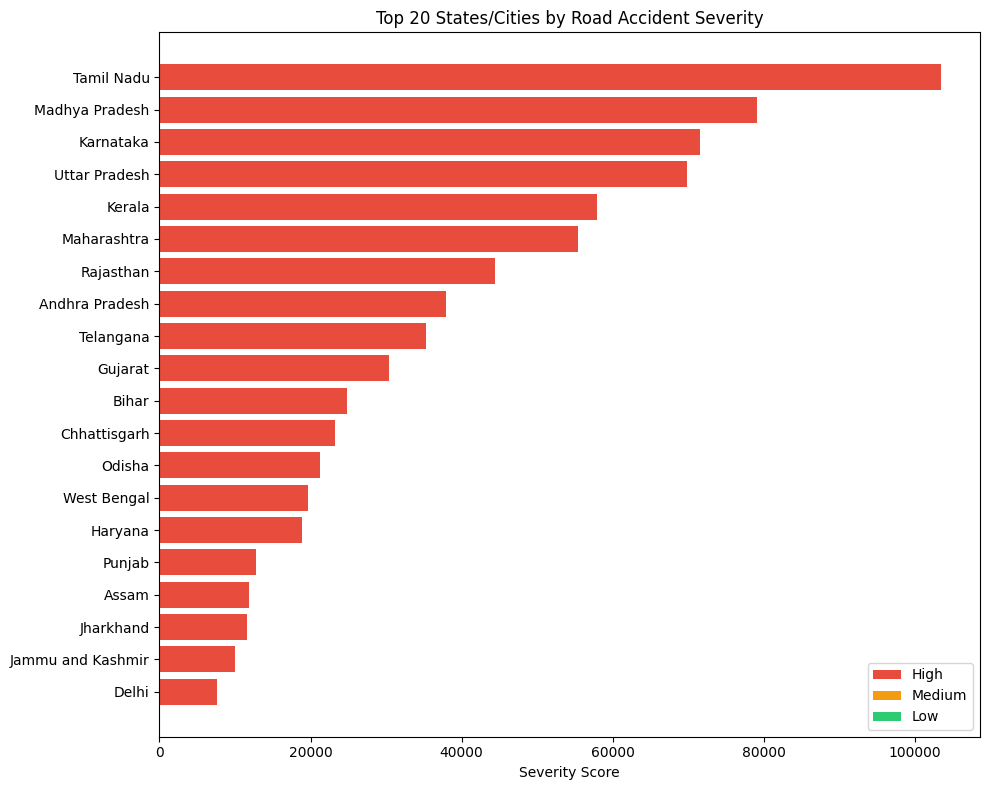

In [7]:
# Cell 7 - Clean chart without Total rows
plt.figure(figsize=(10, 8))
df_sorted = df.sort_values('Severity_Score', ascending=False).head(20)

colors = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}
bar_colors = [colors[str(label)] for label in df_sorted['Severity_Label']]

plt.barh(df_sorted['State/UT/City'], df_sorted['Severity_Score'], color=bar_colors)
plt.xlabel('Severity Score')
plt.title('Top 20 States/Cities by Road Accident Severity')
plt.gca().invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='High'),
                   Patch(facecolor='#f39c12', label='Medium'),
                   Patch(facecolor='#2ecc71', label='Low')]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

In [8]:
# Cell 8 - Prepare data for ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Features we'll use to predict severity
features = ['Road Accidents - Cases', 'Road Accidents - Injured', 
            'Road Accidents - Died', 'Railway Accidents - Cases',
            'Railway Accidents - Died']

X = df[features]
y = df['Severity_Label']

# Encode labels (Low/Medium/High → 0/1/2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, 
                                                      test_size=0.2, 
                                                      random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Classes:", le.classes_)

Training samples: 71
Testing samples: 18
Classes: ['High' 'Low' 'Medium']


In [9]:
# Cell 9 - Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Test it
y_pred = rf_model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.8333333333333334

Detailed Report:
              precision    recall  f1-score   support

        High       1.00      0.75      0.86         8
         Low       0.75      1.00      0.86         3
      Medium       0.75      0.86      0.80         7

    accuracy                           0.83        18
   macro avg       0.83      0.87      0.84        18
weighted avg       0.86      0.83      0.83        18



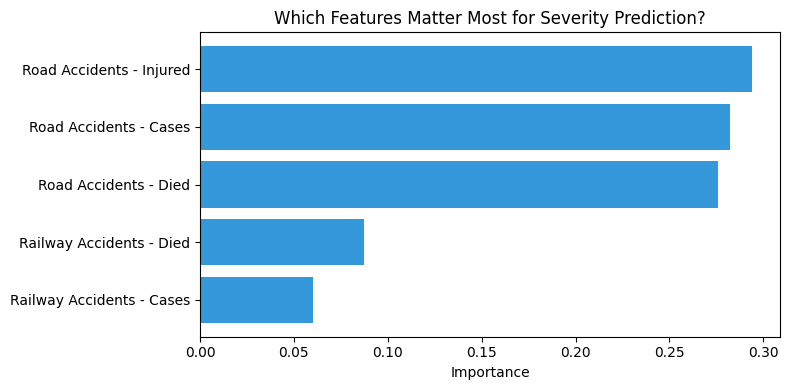

                     Feature  Importance
1   Road Accidents - Injured    0.294158
0     Road Accidents - Cases    0.281995
2      Road Accidents - Died    0.275807
4   Railway Accidents - Died    0.087590
3  Railway Accidents - Cases    0.060450


In [10]:
# Cell 10 - Feature Importance
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='#3498db')
plt.xlabel('Importance')
plt.title('Which Features Matter Most for Severity Prediction?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance)

In [11]:
# Cell 11 - Save the model
import pickle
import os

os.makedirs('models', exist_ok=True)

# Save model and label encoder
with open('models/severity_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model saved successfully to models/ folder!")

Model saved successfully to models/ folder!
